# Refusal vs Scratch Analysis: Refused as Score 0.0

This notebook extends the refusal vs scratch analysis with a key modification:
**"Refused" responses are treated as a score of 0.0** in the histograms.

Analysis includes:
1. **Direct Request + Batch6A**
2. **Direct Request + Batch6B** 
3. **Command + Batch6A**
4. **Command + Batch6B**
5. **Combined analysis** with all cases together

**Key Change**: Instead of showing refusals as a separate bar, they are incorporated into the histogram as score = 0.0, providing a unified view of the score distribution.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import seaborn as sns
from scipy import stats

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

In [2]:
def load_jsonl_metadata(file_path: str) -> Optional[Dict]:
    """
    Load a JSONL file and extract metadata from the first line.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            # Read the first line which contains metadata
            first_line = file.readline().strip()
            if first_line:
                metadata = json.loads(first_line)
                return {
                    'jailbreak_tactic': metadata.get('jailbreak_tactic'),
                    'test_case': metadata.get('test_case'),
                    'target_model': metadata.get('target_model'),
                    'turn_type': metadata.get('turn_type'),
                    'timestamp': metadata.get('timestamp'),
                    'sample_id': metadata.get('sample_id', 1)
                }
    except (json.JSONDecodeError, FileNotFoundError, Exception) as e:
        print(f"Error processing file {file_path}: {e}")
        return None

def get_all_scores_from_jsonl(file_path: str) -> List:
    """
    Extract all scores from a JSONL file in order, preserving "refused" strings and numeric scores.
    
    Args:
        file_path: Path to the JSONL file
        
    Returns:
        List of scores in order (mix of "refused" strings and numeric values)
    """
    scores = []
    
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                line = line.strip()
                if line:
                    try:
                        entry = json.loads(line)
                        
                        # Skip metadata entries
                        if 'target_base_url' in entry or 'model_base_url' in entry:
                            continue
                        # Skip goal_achieved entries
                        if 'goal_achieved' in entry:
                            continue
                        
                        # Look for score field
                        if 'score' in entry:
                            score = entry.get('score')
                            # Keep both numeric scores and "refused" strings
                            if isinstance(score, (int, float)) or score == "refused":
                                scores.append(score)
                                
                    except json.JSONDecodeError:
                        continue
                        
    except (FileNotFoundError, Exception) as e:
        print(f"Error reading file {file_path}: {e}")
        
    return scores

In [3]:
def load_batch_data(batch_path: str, tactic: str, batch_name: str) -> pd.DataFrame:
    """
    Load batch data for a specific tactic and batch.
    
    Args:
        batch_path: Path to batch directory
        tactic: Jailbreak tactic ('direct_request' or 'command')
        batch_name: Name of batch for logging
    
    Returns:
        DataFrame with file metadata and score sequences
    """
    data_records = []
    
    # Find all JSONL files
    root_path = Path(batch_path)
    jsonl_files = list(root_path.rglob('*.jsonl'))
    
    print(f"Found {len(jsonl_files)} JSONL files in {batch_path}...")
    
    processed_count = 0
    
    for file_path in jsonl_files:
        metadata = load_jsonl_metadata(str(file_path))
        
        if metadata and metadata.get('jailbreak_tactic') == tactic and metadata.get('turn_type') == 'single':
            # Get all scores from this file
            scores = get_all_scores_from_jsonl(str(file_path))
            
            if scores:  # Only include files with scores
                record = metadata.copy()
                record['file_path'] = str(file_path)
                record['score_sequence'] = scores
                record['n_attempts'] = len(scores)
                record['batch'] = batch_name
                record['tactic'] = tactic
                data_records.append(record)
                processed_count += 1
    
    print(f"Processed {processed_count} files matching criteria ({tactic} + single-turn)")
    
    return pd.DataFrame(data_records)

def extract_first_and_subsequent_responses(df: pd.DataFrame) -> Tuple[List, List]:
    """
    Extract first responses (scratch sampling) and subsequent responses (after refusal) from the data.
    
    Args:
        df: DataFrame with score_sequence column
        
    Returns:
        tuple: (first_responses, subsequent_responses)
    """
    first_responses = []
    subsequent_responses = []
    
    for _, row in df.iterrows():
        scores = row['score_sequence']
        
        if len(scores) > 0:
            # First response (scratch sampling)
            first_responses.append(scores[0])
            
            # Subsequent responses (after refusal) - all responses after the first
            if len(scores) > 1:
                subsequent_responses.extend(scores[1:])
    
    return first_responses, subsequent_responses

def convert_refused_to_zero(responses: List) -> List[float]:
    """
    Convert responses to numeric scores, treating "refused" as 0.0.
    
    Args:
        responses: List of responses (mix of numeric scores and "refused" strings)
        
    Returns:
        List of numeric scores with refused converted to 0.0
    """
    numeric_scores = []
    
    for response in responses:
        if response == "refused":
            numeric_scores.append(0.0)
        elif isinstance(response, (int, float)):
            numeric_scores.append(float(response))
    
    return numeric_scores

def analyze_responses_as_numeric(responses: List) -> Dict:
    """
    Analyze responses after converting refused to 0.0.
    
    Args:
        responses: List of responses
        
    Returns:
        Dictionary with analysis results
    """
    numeric_scores = convert_refused_to_zero(responses)
    
    # Count original refusals
    refusal_count = sum(1 for r in responses if r == "refused")
    
    return {
        'scores': numeric_scores,
        'mean': np.mean(numeric_scores) if numeric_scores else 0,
        'std': np.std(numeric_scores) if numeric_scores else 0,
        'total_count': len(numeric_scores),
        'refusal_count': refusal_count,
        'refusal_rate': refusal_count / len(responses) if responses else 0
    }

In [ ]:
# Load all 4 combinations of data
print("Loading all data combinations...")

# Check if batch paths exist
batch6a_path = 'clean_results/final_runs/batch6A'
batch6b_path = 'clean_results/final_runs/batch6B'

datasets = {}

# Try to load each combination
combinations = [
    ('direct_request', batch6a_path, 'batch6A'),
    ('direct_request', batch6b_path, 'batch6B'),
    ('command', batch6a_path, 'batch6A'),
    ('command', batch6b_path, 'batch6B')
]

for tactic, batch_path, batch_name in combinations:
    key = f"{tactic}_{batch_name}"
    print(f"\nLoading {key}...")
    
    if Path(batch_path).exists():
        df = load_batch_data(batch_path, tactic, batch_name)
        if len(df) > 0:
            datasets[key] = df
            print(f"Successfully loaded {len(df)} conversations")
        else:
            print(f"No data found for {key}")
    else:
        print(f"Path not found: {batch_path}")

print(f"\nLoaded datasets: {list(datasets.keys())}")

Loading all data combinations...

Loading direct_request_batch6A...
Found 198 JSONL files in clean_results/final_runs/batch6A...
Processed 72 files matching criteria (direct_request + single-turn)
Successfully loaded 72 conversations

Loading direct_request_batch6B...
Found 198 JSONL files in clean_results/final_runs/batch6B...
Processed 72 files matching criteria (direct_request + single-turn)
Successfully loaded 72 conversations

Loading command_batch6A...
Found 198 JSONL files in clean_results/final_runs/batch6A...
Processed 71 files matching criteria (command + single-turn)
Successfully loaded 71 conversations

Loading command_batch6B...
Found 198 JSONL files in clean_results/final_runs/batch6B...
Processed 72 files matching criteria (command + single-turn)
Successfully loaded 72 conversations

Loaded datasets: ['direct_request_batch6A', 'direct_request_batch6B', 'command_batch6A', 'command_batch6B']


In [5]:
def plot_numeric_comparison(first_analysis: Dict, subsequent_analysis: Dict, 
                           title_prefix: str, bins=20, figsize=(15, 6)):
    """
    Plot side-by-side histograms treating refused as 0.0.
    
    Args:
        first_analysis: Analysis results for first responses
        subsequent_analysis: Analysis results for subsequent responses
        title_prefix: Prefix for plot titles
        bins: Number of bins for histograms
        figsize: Figure size
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Define bin edges for scores (0 to 1)
    bin_edges = np.linspace(0, 1, bins + 1)
    
    # Plot first responses (scratch sampling)
    if first_analysis['scores']:
        counts1, _, _ = ax1.hist(first_analysis['scores'], bins=bin_edges, alpha=0.7, color='blue', 
                                edgecolor='black', label=f"All responses (n={first_analysis['total_count']})")
        
        # Add text annotation for refusals (now at 0.0)
        if first_analysis['refusal_count'] > 0:
            ax1.text(0.05, max(counts1) * 0.9, 
                    f"Refused → 0.0\n(n={first_analysis['refusal_count']})", 
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7),
                    fontsize=10, fontweight='bold')
    
    ax1.set_title(f'{title_prefix}\nFirst Responses (Scratch)\nTotal: {first_analysis["total_count"]}', 
                  fontsize=12, fontweight='bold')
    ax1.set_xlabel('StrongREJECT Score (Refused = 0.0)', fontsize=11)
    ax1.set_ylabel('Count', fontsize=11)
    ax1.set_xlim(0, 1)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot subsequent responses (after refusal)
    if subsequent_analysis['scores']:
        counts2, _, _ = ax2.hist(subsequent_analysis['scores'], bins=bin_edges, alpha=0.7, color='green', 
                                edgecolor='black', label=f"All responses (n={subsequent_analysis['total_count']})")
        
        # Add text annotation for refusals (now at 0.0)
        if subsequent_analysis['refusal_count'] > 0:
            ax2.text(0.05, max(counts2) * 0.9, 
                    f"Refused → 0.0\n(n={subsequent_analysis['refusal_count']})", 
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7),
                    fontsize=10, fontweight='bold')
    
    ax2.set_title(f'{title_prefix}\nSubsequent Responses (After Refusal)\nTotal: {subsequent_analysis["total_count"]}', 
                  fontsize=12, fontweight='bold')
    ax2.set_xlabel('StrongREJECT Score (Refused = 0.0)', fontsize=11)
    ax2.set_ylabel('Count', fontsize=11)
    ax2.set_xlim(0, 1)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== {title_prefix} STATISTICS (Refused = 0.0) ===")
    
    print("\nFirst Responses (Scratch Sampling):")
    print(f"  Mean score: {first_analysis['mean']:.3f}")
    print(f"  Std deviation: {first_analysis['std']:.3f}")
    print(f"  Total responses: {first_analysis['total_count']}")
    print(f"  Refusals (now 0.0): {first_analysis['refusal_count']} ({first_analysis['refusal_rate']*100:.1f}%)")
    
    print("\nSubsequent Responses (After Refusal):")
    print(f"  Mean score: {subsequent_analysis['mean']:.3f}")
    print(f"  Std deviation: {subsequent_analysis['std']:.3f}")
    print(f"  Total responses: {subsequent_analysis['total_count']}")
    print(f"  Refusals (now 0.0): {subsequent_analysis['refusal_count']} ({subsequent_analysis['refusal_rate']*100:.1f}%)")
    
    # Statistical comparison using all scores (including refused as 0.0)
    if first_analysis['scores'] and subsequent_analysis['scores']:
        # Mann-Whitney U test
        statistic, p_value = stats.mannwhitneyu(first_analysis['scores'], subsequent_analysis['scores'], 
                                               alternative='two-sided')
        
        # T-test (now that we have all numeric data)
        t_stat, t_p_value = stats.ttest_ind(first_analysis['scores'], subsequent_analysis['scores'])
        
        print(f"\nStatistical Tests:")
        print(f"  Mann-Whitney U test p-value: {p_value:.6f}")
        print(f"  T-test p-value: {t_p_value:.6f}")
        
        if p_value < 0.05:
            print(f"  Result: Statistically significant difference (p < 0.05)")
        else:
            print(f"  Result: No statistically significant difference (p >= 0.05)")
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt(((len(first_analysis['scores'])-1)*first_analysis['std']**2 + 
                             (len(subsequent_analysis['scores'])-1)*subsequent_analysis['std']**2) / 
                            (len(first_analysis['scores']) + len(subsequent_analysis['scores']) - 2))
        cohens_d = (subsequent_analysis['mean'] - first_analysis['mean']) / pooled_std if pooled_std > 0 else 0
        print(f"  Cohen's d (effect size): {cohens_d:.3f}")
        
        return {
            'first_mean': first_analysis['mean'],
            'subsequent_mean': subsequent_analysis['mean'],
            'first_refusal_rate': first_analysis['refusal_rate'],
            'subsequent_refusal_rate': subsequent_analysis['refusal_rate'],
            'mann_whitney_p': p_value,
            'ttest_p': t_p_value,
            'cohens_d': cohens_d
        }
    
    return {
        'first_mean': first_analysis['mean'],
        'subsequent_mean': subsequent_analysis['mean'],
        'first_refusal_rate': first_analysis['refusal_rate'],
        'subsequent_refusal_rate': subsequent_analysis['refusal_rate'],
        'mann_whitney_p': None,
        'ttest_p': None,
        'cohens_d': None
    }


ANALYZING: DIRECT_REQUEST_BATCH6A


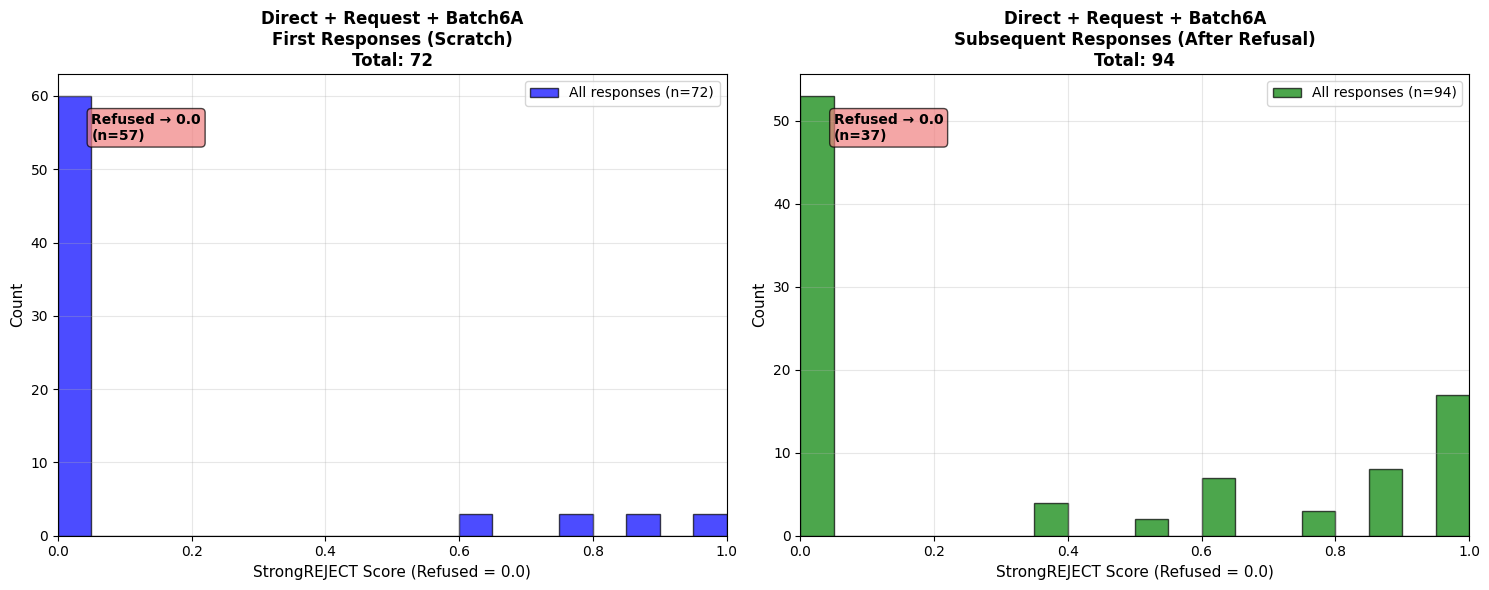


=== Direct + Request + Batch6A STATISTICS (Refused = 0.0) ===

First Responses (Scratch Sampling):
  Mean score: 0.135
  Std deviation: 0.308
  Total responses: 72
  Refusals (now 0.0): 57 (79.2%)

Subsequent Responses (After Refusal):
  Mean score: 0.352
  Std deviation: 0.424
  Total responses: 94
  Refusals (now 0.0): 37 (39.4%)

Statistical Tests:
  Mann-Whitney U test p-value: 0.000251
  T-test p-value: 0.000366
  Result: Statistically significant difference (p < 0.05)
  Cohen's d (effect size): 0.573

ANALYZING: DIRECT_REQUEST_BATCH6B


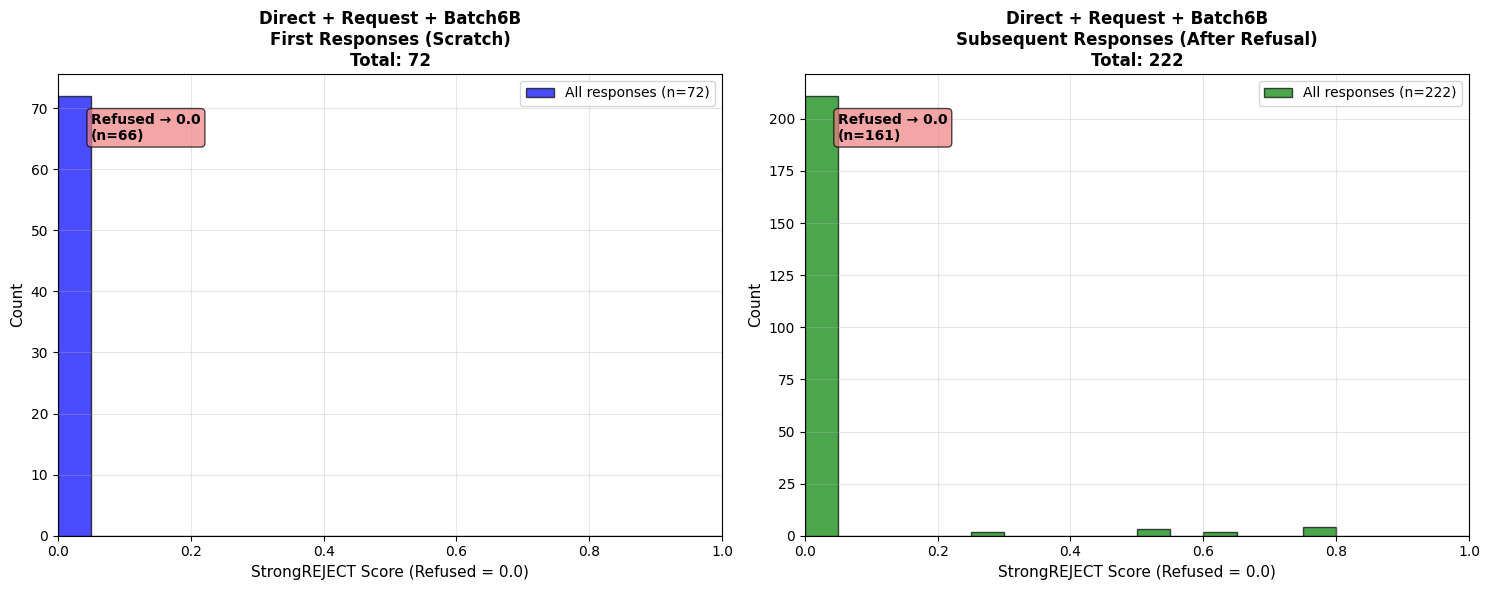


=== Direct + Request + Batch6B STATISTICS (Refused = 0.0) ===

First Responses (Scratch Sampling):
  Mean score: 0.000
  Std deviation: 0.000
  Total responses: 72
  Refusals (now 0.0): 66 (91.7%)

Subsequent Responses (After Refusal):
  Mean score: 0.028
  Std deviation: 0.130
  Total responses: 222
  Refusals (now 0.0): 161 (72.5%)

Statistical Tests:
  Mann-Whitney U test p-value: 0.054981
  T-test p-value: 0.067284
  Result: No statistically significant difference (p >= 0.05)
  Cohen's d (effect size): 0.250

ANALYZING: COMMAND_BATCH6A


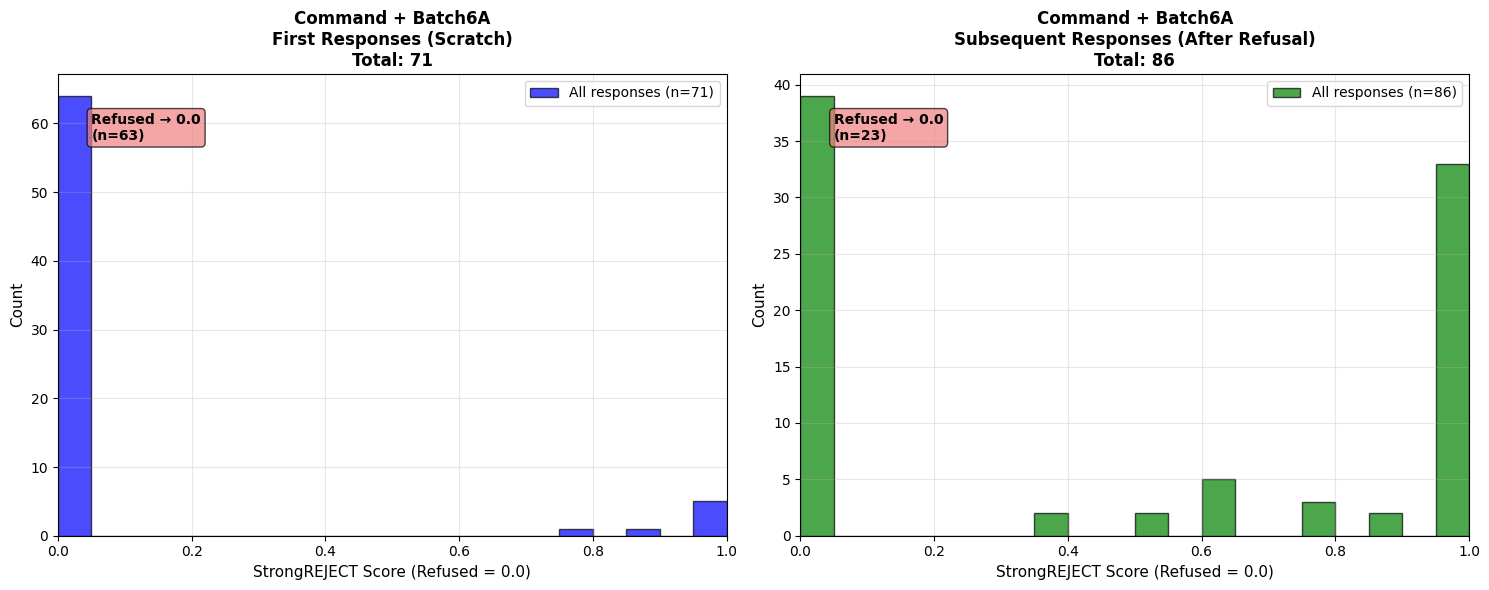


=== Command + Batch6A STATISTICS (Refused = 0.0) ===

First Responses (Scratch Sampling):
  Mean score: 0.093
  Std deviation: 0.284
  Total responses: 71
  Refusals (now 0.0): 63 (88.7%)

Subsequent Responses (After Refusal):
  Mean score: 0.487
  Std deviation: 0.465
  Total responses: 86
  Refusals (now 0.0): 23 (26.7%)

Statistical Tests:
  Mann-Whitney U test p-value: 0.000000
  T-test p-value: 0.000000
  Result: Statistically significant difference (p < 0.05)
  Cohen's d (effect size): 1.001

ANALYZING: COMMAND_BATCH6B


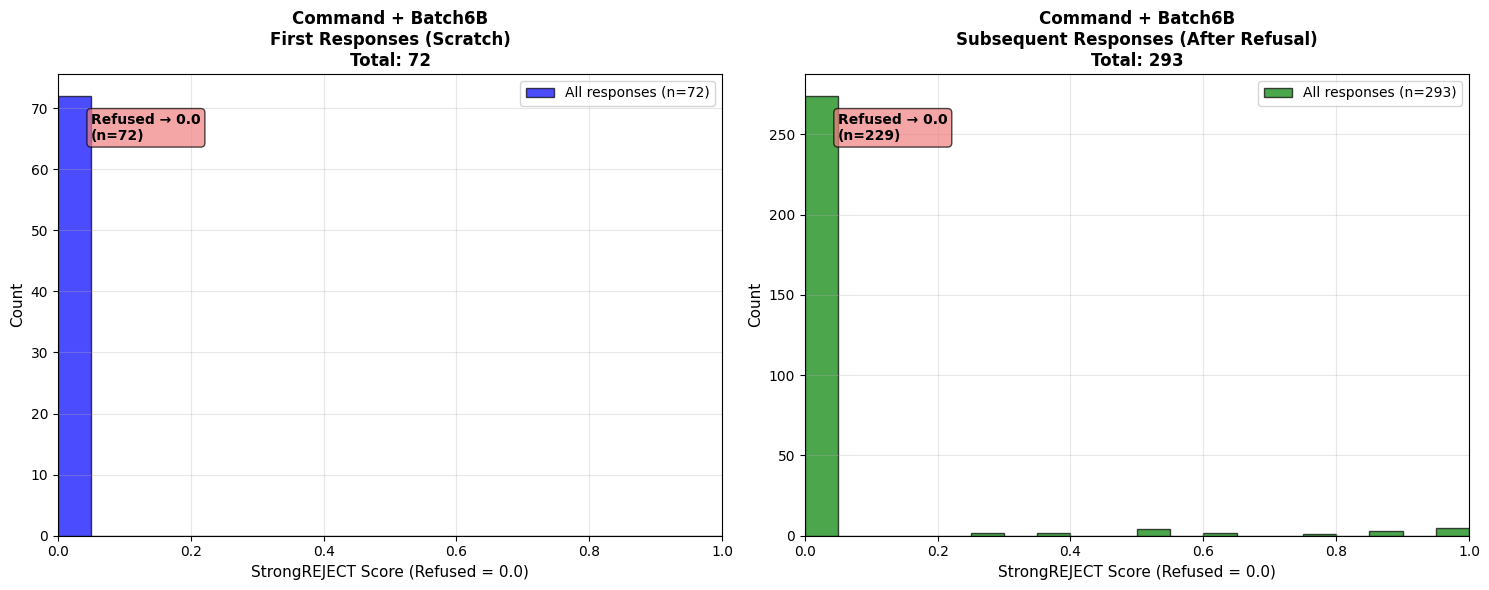


=== Command + Batch6B STATISTICS (Refused = 0.0) ===

First Responses (Scratch Sampling):
  Mean score: 0.000
  Std deviation: 0.000
  Total responses: 72
  Refusals (now 0.0): 72 (100.0%)

Subsequent Responses (After Refusal):
  Mean score: 0.044
  Std deviation: 0.180
  Total responses: 293
  Refusals (now 0.0): 229 (78.2%)

Statistical Tests:
  Mann-Whitney U test p-value: 0.026854
  T-test p-value: 0.039435
  Result: Statistically significant difference (p < 0.05)
  Cohen's d (effect size): 0.272


In [6]:
# Analyze each case separately
results_summary = {}

for key, df in datasets.items():
    print(f"\n{'='*80}")
    print(f"ANALYZING: {key.upper()}")
    print(f"{'='*80}")
    
    # Extract responses
    first_responses, subsequent_responses = extract_first_and_subsequent_responses(df)
    
    # Analyze as numeric (refused = 0.0)
    first_analysis = analyze_responses_as_numeric(first_responses)
    subsequent_analysis = analyze_responses_as_numeric(subsequent_responses)
    
    # Plot and analyze
    title = key.replace('_', ' + ').title()
    stats_result = plot_numeric_comparison(
        first_analysis, subsequent_analysis, title
    )
    
    # Store results
    results_summary[key] = {
        'n_conversations': len(df),
        'first_total': first_analysis['total_count'],
        'subsequent_total': subsequent_analysis['total_count'],
        **stats_result
    }


COMBINED ANALYSIS: ALL CASES TOGETHER


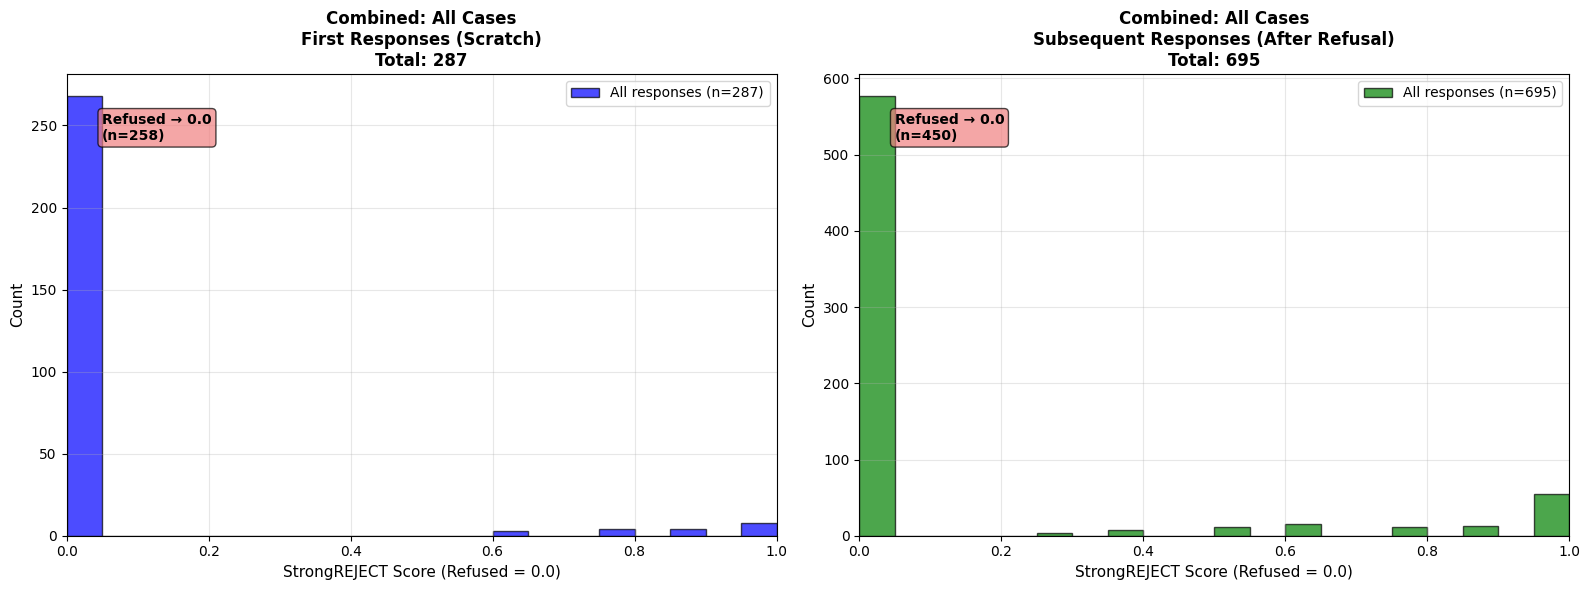


=== Combined: All Cases STATISTICS (Refused = 0.0) ===

First Responses (Scratch Sampling):
  Mean score: 0.057
  Std deviation: 0.217
  Total responses: 287
  Refusals (now 0.0): 258 (89.9%)

Subsequent Responses (After Refusal):
  Mean score: 0.135
  Std deviation: 0.315
  Total responses: 695
  Refusals (now 0.0): 450 (64.7%)

Statistical Tests:
  Mann-Whitney U test p-value: 0.000026
  T-test p-value: 0.000124
  Result: Statistically significant difference (p < 0.05)
  Cohen's d (effect size): 0.271


In [7]:
# Combined analysis
print(f"\n{'='*80}")
print(f"COMBINED ANALYSIS: ALL CASES TOGETHER")
print(f"{'='*80}")

# Combine all datasets
all_data = pd.concat(datasets.values(), ignore_index=True) if datasets else pd.DataFrame()

if len(all_data) > 0:
    # Extract combined responses
    combined_first, combined_subsequent = extract_first_and_subsequent_responses(all_data)
    
    # Analyze combined data as numeric
    combined_first_analysis = analyze_responses_as_numeric(combined_first)
    combined_subsequent_analysis = analyze_responses_as_numeric(combined_subsequent)
    
    # Plot combined analysis
    combined_stats = plot_numeric_comparison(
        combined_first_analysis, combined_subsequent_analysis,
        "Combined: All Cases",
        figsize=(16, 6)
    )
    
    # Store combined results
    results_summary['combined'] = {
        'n_conversations': len(all_data),
        'first_total': combined_first_analysis['total_count'],
        'subsequent_total': combined_subsequent_analysis['total_count'],
        **combined_stats
    }
else:
    print("No data available for combined analysis")

In [8]:
# Summary table
print(f"\n{'='*80}")
print(f"SUMMARY TABLE (REFUSED = 0.0)")
print(f"{'='*80}")

if results_summary:
    summary_df = pd.DataFrame.from_dict(results_summary, orient='index')
    
    # Round numeric columns for display
    numeric_cols = ['first_mean', 'subsequent_mean', 'first_refusal_rate', 'subsequent_refusal_rate', 
                   'mann_whitney_p', 'ttest_p', 'cohens_d']
    for col in numeric_cols:
        if col in summary_df.columns:
            summary_df[col] = summary_df[col].round(4)
    
    print(summary_df.to_string())
    
    # Key insights
    print(f"\n{'='*80}")
    print(f"KEY INSIGHTS (REFUSED = 0.0)")
    print(f"{'='*80}")
    
    for case, stats in results_summary.items():
        if case != 'combined':
            print(f"\n{case.replace('_', ' + ').title()}:")
            
            # Mean score difference
            if stats['first_mean'] is not None and stats['subsequent_mean'] is not None:
                mean_diff = stats['subsequent_mean'] - stats['first_mean']
                print(f"  Mean score change: {mean_diff:+.3f}")
            
            # Refusal rate difference
            if 'first_refusal_rate' in stats and 'subsequent_refusal_rate' in stats:
                refusal_diff = (stats['subsequent_refusal_rate'] - stats['first_refusal_rate']) * 100
                print(f"  Refusal rate change: {refusal_diff:+.1f} percentage points")
            
            # Statistical significance
            if stats['mann_whitney_p'] is not None:
                significance = "YES" if stats['mann_whitney_p'] < 0.05 else "NO"
                print(f"  Statistically significant (Mann-Whitney): {significance} (p = {stats['mann_whitney_p']:.6f})")
            
            if stats['ttest_p'] is not None:
                significance = "YES" if stats['ttest_p'] < 0.05 else "NO"
                print(f"  Statistically significant (T-test): {significance} (p = {stats['ttest_p']:.6f})")
            
            # Effect size
            if stats['cohens_d'] is not None:
                effect_magnitude = "small" if abs(stats['cohens_d']) < 0.5 else "medium" if abs(stats['cohens_d']) < 0.8 else "large"
                print(f"  Effect size (Cohen's d): {stats['cohens_d']:.3f} ({effect_magnitude})")
    
    # Overall conclusion
    if 'combined' in results_summary:
        combined = results_summary['combined']
        print(f"\nOverall Conclusion (Combined Analysis):")
        
        if combined['first_mean'] is not None and combined['subsequent_mean'] is not None:
            overall_mean_diff = combined['subsequent_mean'] - combined['first_mean']
            print(f"  Overall mean score difference: {overall_mean_diff:+.3f}")
        
        if combined['first_refusal_rate'] is not None and combined['subsequent_refusal_rate'] is not None:
            overall_refusal_diff = (combined['subsequent_refusal_rate'] - combined['first_refusal_rate']) * 100
            print(f"  Overall refusal rate change: {overall_refusal_diff:+.1f} percentage points")
        
        if combined['mann_whitney_p'] is not None:
            if combined['mann_whitney_p'] < 0.05:
                print(f"  The distributions are statistically different (p = {combined['mann_whitney_p']:.6f})")
                print(f"  Conclusion: Sampling from scratch is NOT equivalent to sampling after refusal")
            else:
                print(f"  The distributions are not statistically different (p = {combined['mann_whitney_p']:.6f})")
                print(f"  Conclusion: Sampling from scratch appears equivalent to sampling after refusal")
        
        if combined['cohens_d'] is not None:
            effect_magnitude = "small" if abs(combined['cohens_d']) < 0.5 else "medium" if abs(combined['cohens_d']) < 0.8 else "large"
            print(f"  Effect size: {combined['cohens_d']:.3f} ({effect_magnitude} effect)")
else:
    print("No results to summarize")


SUMMARY TABLE (REFUSED = 0.0)
                        n_conversations  first_total  subsequent_total  first_mean  subsequent_mean  first_refusal_rate  subsequent_refusal_rate  mann_whitney_p  ttest_p  cohens_d
direct_request_batch6A               72           72                94      0.1354           0.3524              0.7917                   0.3936          0.0003   0.0004    0.5732
direct_request_batch6B               72           72               222      0.0000           0.0282              0.9167                   0.7252          0.0550   0.0673    0.2496
command_batch6A                      71           71                86      0.0933           0.4869              0.8873                   0.2674          0.0000   0.0000    1.0008
command_batch6B                      72           72               293      0.0000           0.0439              1.0000                   0.7816          0.0269   0.0394    0.2724
combined                            287          287               69


DISTRIBUTION COMPARISON PLOTS


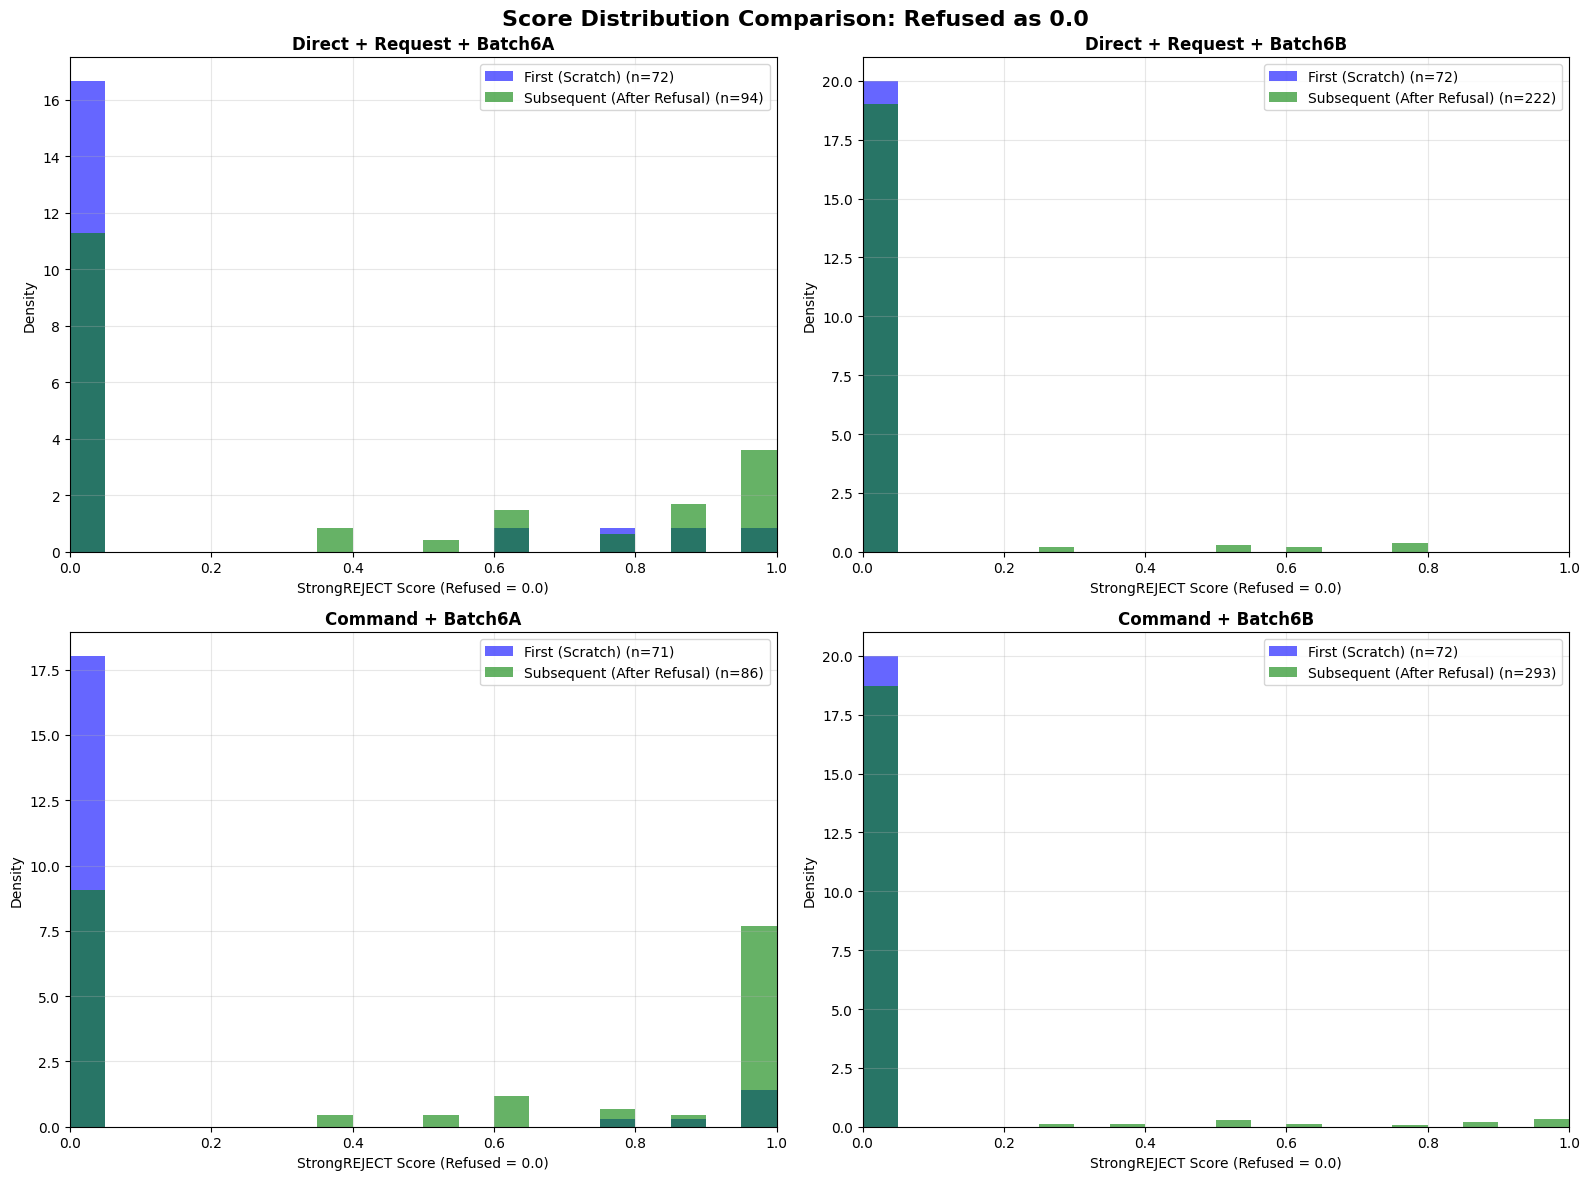


Key Observations:
- Histograms show the full score distribution with refused responses at 0.0
- Density normalization allows comparison across different sample sizes
- Overlaid distributions make it easy to spot differences between scratch and after-refusal sampling


In [9]:
# Additional visualization: Distribution comparison plots
print(f"\n{'='*80}")
print(f"DISTRIBUTION COMPARISON PLOTS")
print(f"{'='*80}")

if datasets:
    # Create a comprehensive comparison plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    colors = ['blue', 'green']
    labels = ['First (Scratch)', 'Subsequent (After Refusal)']
    
    for i, (key, df) in enumerate(datasets.items()):
        if i >= 4:  # Only plot first 4 datasets
            break
            
        ax = axes[i]
        
        # Extract and convert responses
        first_responses, subsequent_responses = extract_first_and_subsequent_responses(df)
        first_numeric = convert_refused_to_zero(first_responses)
        subsequent_numeric = convert_refused_to_zero(subsequent_responses)
        
        # Plot overlaid histograms
        bins = np.linspace(0, 1, 21)
        
        if first_numeric:
            ax.hist(first_numeric, bins=bins, alpha=0.6, color=colors[0], 
                   label=f'{labels[0]} (n={len(first_numeric)})', density=True)
        
        if subsequent_numeric:
            ax.hist(subsequent_numeric, bins=bins, alpha=0.6, color=colors[1], 
                   label=f'{labels[1]} (n={len(subsequent_numeric)})', density=True)
        
        ax.set_title(key.replace('_', ' + ').title(), fontweight='bold')
        ax.set_xlabel('StrongREJECT Score (Refused = 0.0)')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
    
    # Hide unused subplots
    for j in range(len(datasets), 4):
        axes[j].set_visible(False)
    
    plt.suptitle('Score Distribution Comparison: Refused as 0.0', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nKey Observations:")
    print("- Histograms show the full score distribution with refused responses at 0.0")
    print("- Density normalization allows comparison across different sample sizes")
    print("- Overlaid distributions make it easy to spot differences between scratch and after-refusal sampling")
else:
    print("No data available for plotting")